### Que sinais antecedem a evasão de um aluno no Ensino Superior Online? Como aumentar o engajamento para evitar essa situação? Estas são as perguntas que este projeto busca responder!

In [59]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [60]:
# Bibliotecas necessárias:

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, QuantileTransformer
import statsmodels.api as sm
from scipy import stats

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
# Carregando os Dados

df_alunos_teste = pd.read_csv('/content/drive/My Drive/desafio_principia/alunos_teste.csv')
df_acessos_conteudo_teste = pd.read_csv('/content/drive/My Drive/desafio_principia/acessos_conteudo_teste.csv')
df_provas_teste = pd.read_csv('/content/drive/My Drive/desafio_principia/provas_teste.csv')

In [62]:
# Visão geral das informações das tabelas:

print('***** DF ALUNOS_TESTE: tabela contendo os alunos de determinado semestre e as disciplinas nas quais ele está matriculado')
print(df_alunos_teste.head(3))

print('\n ***** DF ACESSOS_CONTEUDO_TESTE: tabela contendo os acessos ao conteúdo digital (material para estudos) realizados pelos alunos nesse mesmo semestre')
print(df_acessos_conteudo_teste.head(3))

print('\n ***** DF PROVAS TESTE: provas realizadas pelos alunos nesse mesmo semestre')
print(df_provas_teste.head(3))

***** DF ALUNOS_TESTE: tabela contendo os alunos de determinado semestre e as disciplinas nas quais ele está matriculado
      MATRICULA DISCIPLINA
0  202204035316    DGT0336
1  202110113321    CCJ0164
2  202001682635    DGT0002

 ***** DF ACESSOS_CONTEUDO_TESTE: tabela contendo os acessos ao conteúdo digital (material para estudos) realizados pelos alunos nesse mesmo semestre
      DATA_HORA_ACESSO  TEMPO_ACESSO_MINUTOS     MATRICULA DISCIPLINA
0  2022-02-15 00:01:31                     0  202001189726    EGT0019
1  2022-02-16 14:05:00                    54  202001189726    EGT0019
2  2022-02-20 11:32:13                    28  202001189726    EGT0019

 ***** DF PROVAS TESTE: provas realizadas pelos alunos nesse mesmo semestre
   DATA_HORA_AVALIACAO TIPO_AVALIACAO     MATRICULA DISCIPLINA
0  2022-03-02 17:24:00             EX  202008669936    EGT0047
1  2022-03-03 14:01:49             EX  202008669936    ECJ0004
2  2022-02-21 22:53:41             EX  202008669936    EGT0023


In [63]:
# Visão Geral tipos dos dados:

print('***** DF ACESSOS_CONTEUDO_TESTE *****')
print(df_acessos_conteudo_teste.dtypes)

print('\n ***** DF ACESSOS_CONTEUDO_TESTE *****')
print(df_provas_teste.dtypes)

***** DF ACESSOS_CONTEUDO_TESTE *****
DATA_HORA_ACESSO        object
TEMPO_ACESSO_MINUTOS     int64
MATRICULA                int64
DISCIPLINA              object
dtype: object

 ***** DF ACESSOS_CONTEUDO_TESTE *****
DATA_HORA_AVALIACAO    object
TIPO_AVALIACAO         object
MATRICULA               int64
DISCIPLINA             object
dtype: object


In [64]:
# Tratamento:

df_acessos_conteudo_teste['DATA_HORA_ACESSO'] = pd.to_datetime(df_acessos_conteudo_teste['DATA_HORA_ACESSO'])
df_provas_teste['DATA_HORA_AVALIACAO'] = pd.to_datetime(df_provas_teste['DATA_HORA_AVALIACAO'])

df_alunos_teste['MATRICULA'] = df_alunos_teste['MATRICULA'].astype(str)
df_acessos_conteudo_teste['MATRICULA'] = df_acessos_conteudo_teste['MATRICULA'].astype(str)
df_provas_teste['MATRICULA'] = df_provas_teste['MATRICULA'].astype(str)

df_alunos_teste['KEY'] = df_alunos_teste['MATRICULA'].astype(str) + '_' + df_alunos_teste['DISCIPLINA'].astype(str)
df_acessos_conteudo_teste['KEY'] = df_acessos_conteudo_teste['MATRICULA'].astype(str) + '_' + df_acessos_conteudo_teste['DISCIPLINA'].astype(str)
df_provas_teste['KEY'] = df_provas_teste['MATRICULA'].astype(str) + '_' + df_provas_teste['DISCIPLINA'].astype(str)

In [65]:
df_provas_teste['TIPO_AVALIACAO'].value_counts(normalize=True) * 100

,proportion
TIPO_AVALIACAO,
EX,55.226390
SM,23.878060
AV,17.145533
AVS,3.750016


In [66]:
# Checando valores ausentes:

print('***** DF ALUNOS_TESTE *****')
print(df_alunos_teste.notnull().sum()/df_alunos_teste.shape[0])

print('\n ***** DF ACESSOS_CONTEUDO_TESTE *****')
print(df_acessos_conteudo_teste.notnull().sum()/df_acessos_conteudo_teste.shape[0])

print('\n ***** DF PROVAS_TESTE *****')
print(df_provas_teste.notnull().sum()/df_provas_teste.shape[0])

***** DF ALUNOS_TESTE *****
MATRICULA     1.0
DISCIPLINA    1.0
KEY           1.0
dtype: float64

 ***** DF ACESSOS_CONTEUDO_TESTE *****
DATA_HORA_ACESSO        1.0
TEMPO_ACESSO_MINUTOS    1.0
MATRICULA               1.0
DISCIPLINA              1.0
KEY                     1.0
dtype: float64

 ***** DF PROVAS_TESTE *****
DATA_HORA_AVALIACAO    1.0
TIPO_AVALIACAO         1.0
MATRICULA              1.0
DISCIPLINA             1.0
KEY                    1.0
dtype: float64


In [67]:
# Agregando os dados **ACESSO CONTEÚDO**:

df_features_acessos = df_acessos_conteudo_teste.groupby('KEY').agg(
    tempo_total_na_plataforma=('TEMPO_ACESSO_MINUTOS', 'sum'),
    tempo_medio_por_visita=('TEMPO_ACESSO_MINUTOS', 'mean'),
    tempo_mediano_por_visita=('TEMPO_ACESSO_MINUTOS', 'median'),
    std_tempo_visita=('TEMPO_ACESSO_MINUTOS', 'std'),
    tempo_de_visita_maximo=('TEMPO_ACESSO_MINUTOS', 'max'),
    primeiro_acesso=('DATA_HORA_ACESSO', 'min'),
    ultimo_acesso=('DATA_HORA_ACESSO', 'max'),
    numero_de_visitas=('DATA_HORA_ACESSO', 'count')
).reset_index()

df_features_acessos.head(3)

,KEY,tempo_total_na_plataforma,tempo_medio_por_visita,tempo_mediano_por_visita,std_tempo_visita,tempo_de_visita_maximo,primeiro_acesso,ultimo_acesso,numero_de_visitas
0,200002138231_EEX0057,15,7.50,7.5,10.606602,15,2022-03-23 00:43:42,2022-04-20 00:18:32,2
1,200002138231_EGT0003,37,9.25,7.5,8.460693,20,2022-03-24 02:08:31,2022-04-27 00:37:03,4
2,200002138231_EGT0004,0,0.00,0.0,0.000000,0,2022-03-29 00:24:33,2022-04-27 00:35:42,2


In [68]:
df_features_acessos['intervalo_dias_entre_primeiro_e_ultimo_acesso'] = (df_features_acessos['ultimo_acesso'] - df_features_acessos['primeiro_acesso']).dt.days
df_features_acessos['media_acesso_dias'] = ((df_features_acessos['ultimo_acesso'] - df_features_acessos['primeiro_acesso']).dt.days)/df_features_acessos['numero_de_visitas']

In [69]:
# Agregando os dados **PROVAS TESTE**:

df_features_test = pd.crosstab(
    df_provas_teste['KEY'],
    df_provas_teste['TIPO_AVALIACAO']
)

df_features_test = df_features_test.rename(columns={
    'SM': 'numero_prova_sm',
    'AV': 'numero_prova_av',
    'EX': 'numero_exercicios',
    'AVS': 'numero_prova_avs'
}).reset_index()

df_features_test.head(3)

TIPO_AVALIACAO,KEY,numero_prova_av,numero_prova_avs,numero_exercicios,numero_prova_sm
0,199901175396_CCE1311,1,0,0,1
1,199901175396_GST0626,1,0,0,1
2,199901175396_GST0642,1,0,0,1


In [70]:
df_features_test['numero_de_provas'] = df_features_test['numero_prova_av'] + \
                                      df_features_test['numero_prova_avs']

In [71]:
df_ex = df_provas_teste[df_provas_teste['TIPO_AVALIACAO'] == 'EX']
df_test = df_provas_teste[(df_provas_teste['TIPO_AVALIACAO'] != 'EX') &
                          (df_provas_teste['TIPO_AVALIACAO'] != 'SM')]

df_ex_agg = df_ex.groupby('KEY').agg(
    data_primeiro_exercicio=('DATA_HORA_AVALIACAO', 'min'),
    data_ultimo_exercicio=('DATA_HORA_AVALIACAO', 'max')
).reset_index()

df_test_agg = df_test.groupby('KEY').agg(
    data_primeira_prova=('DATA_HORA_AVALIACAO', 'min'),
    data_ultima_prova=('DATA_HORA_AVALIACAO', 'max')
).reset_index()

In [72]:
df_features_test2 = pd.merge(df_features_test, df_ex_agg, on='KEY', how='left')
df_features_test2 = pd.merge(df_features_test2, df_test_agg, on='KEY',
                             how='left')

df_features_test2['intervalo_dias_entre_primeira_e_ultima_prova'] = \
 (df_features_test2['data_ultima_prova'] - \
  df_features_test2['data_primeira_prova']).dt.days

df_features_test2['intervalo_dias_entre_primeiro_e_ultimo_exercicio'] = \
 (df_features_test2['data_ultimo_exercicio'] - \
  df_features_test2['data_primeiro_exercicio']).dt.days

In [73]:
# Integrando os dados:

df_features = pd.merge(df_alunos_teste, df_features_acessos, on='KEY', how='left')
df_features = pd.merge(df_features, df_features_test2, on='KEY', how='left')

df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1477825 entries, 0 to 1477824
Data columns (total 24 columns):
 #   Column                                            Non-Null Count    Dtype         
---  ------                                            --------------    -----         
 0   MATRICULA                                         1477825 non-null  object        
 1   DISCIPLINA                                        1477825 non-null  object        
 2   KEY                                               1477825 non-null  object        
 3   tempo_total_na_plataforma                         916898 non-null   float64       
 4   tempo_medio_por_visita                            916898 non-null   float64       
 5   tempo_mediano_por_visita                          916898 non-null   float64       
 6   std_tempo_visita                                  818236 non-null   float64       
 7   tempo_de_visita_maximo                            916898 non-null   float64       
 8   pr

In [74]:
# Tratamento Dados Integrados:


variaveis = ['tempo_total_na_plataforma', 'tempo_medio_por_visita',
             'tempo_mediano_por_visita', 'std_tempo_visita',
             'tempo_de_visita_maximo', 'primeiro_acesso',
             'ultimo_acesso', 'numero_de_visitas',
             'intervalo_dias_entre_primeiro_e_ultimo_acesso',
             'media_acesso_dias', 'numero_prova_sm',
             'numero_prova_av', 'numero_exercicios', 'numero_prova_avs',
             'numero_de_provas', 'intervalo_dias_entre_primeira_e_ultima_prova',
             'intervalo_dias_entre_primeiro_e_ultimo_exercicio']

df_features[variaveis] = df_features[variaveis].fillna(0)

In [75]:
df_features['evad'] = df_features['numero_prova_sm'] == 0

In [76]:
# Análise Exploratória

df_evadiram = df_features[df_features['evad']].reset_index(drop=True)
df_nao_evadiram = df_features[~df_features['evad']].reset_index(drop=True)

In [77]:
# Distribuições:

index = ['1%', '5%', '10%', 'Q1', 'Mediana', 'Q3', '90%', '95%', '99%', '99,5%',
         'Máximo']
quantis = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 1]

# Alunos que não evadiram:

colunas_numericas_nao_evad = df_nao_evadiram.select_dtypes(
    include=['number'])
colunas_numericas_nao_evad = colunas_numericas_nao_evad.drop(columns=
 ['MATRICULA', 'numero_prova_sm'], errors='ignore')
quartis_nao_evad = colunas_numericas_nao_evad.quantile(quantis)
quartis_nao_evad.index = index
quartis_nao_evad.columns = ['NAO_EVAD_' + col for col in quartis_nao_evad.columns]

# Alunos que evadiram:

colunas_numericas_evad = df_evadiram.select_dtypes(include=['number'])
colunas_numericas_evad = colunas_numericas_evad.drop(columns=
 ['MATRICULA', 'numero_prova_sm'], errors='ignore')
quartis_evad = colunas_numericas_evad.quantile(quantis)
quartis_evad.index = index
quartis_evad.columns = ['EVAD_' + col for col in quartis_evad.columns]

In [78]:
# CONCAT:

df = pd.concat([quartis_nao_evad, quartis_evad], axis=1)
colunas = df.columns
n_cols = int((df.shape[1])/2)

cols_nao_evad = colunas[:n_cols]
cols_evad = colunas[n_cols:]

nova_ordem = []

for i in range(n_cols):
    nova_ordem.append(cols_nao_evad[i])
    nova_ordem.append(cols_evad[i])

df = df[nova_ordem]

df

,NAO_EVAD_tempo_total_na_plataforma,EVAD_tempo_total_na_plataforma,NAO_EVAD_tempo_medio_por_visita,EVAD_tempo_medio_por_visita,NAO_EVAD_tempo_mediano_por_visita,EVAD_tempo_mediano_por_visita,NAO_EVAD_std_tempo_visita,EVAD_std_tempo_visita,NAO_EVAD_tempo_de_visita_maximo,EVAD_tempo_de_visita_maximo,...,NAO_EVAD_numero_prova_avs,EVAD_numero_prova_avs,NAO_EVAD_numero_exercicios,EVAD_numero_exercicios,NAO_EVAD_numero_de_provas,EVAD_numero_de_provas,NAO_EVAD_intervalo_dias_entre_primeira_e_ultima_prova,EVAD_intervalo_dias_entre_primeira_e_ultima_prova,NAO_EVAD_intervalo_dias_entre_primeiro_e_ultimo_exercicio,EVAD_intervalo_dias_entre_primeiro_e_ultimo_exercicio
1%,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5%,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10%,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Q1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Mediana,53.0,0.0,8.812500,0.000000,2.0,0.0,8.621678,0.000000,29.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Q3,309.0,18.0,28.250000,4.272727,19.0,1.0,28.140933,1.914854,86.0,12.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
90%,735.0,168.0,49.666667,28.500000,42.0,21.5,48.009422,25.729577,153.0,70.0,...,1.0,0.0,10.0,1.0,2.0,1.0,14.0,0.0,7.0,0.0
95%,1103.0,354.0,64.666667,46.727273,57.0,41.0,62.329756,40.753045,201.0,115.0,...,1.0,1.0,12.0,1.0,2.0,1.0,27.0,0.0,38.0,0.0
99%,2146.0,981.0,103.833333,89.000000,99.0,84.5,94.558359,75.722009,308.0,217.0,...,1.0,1.0,38.0,10.0,2.0,2.0,34.0,11.0,84.0,3.0
"99,5%",2706.0,1333.0,120.428571,109.515577,117.5,107.0,108.510081,90.509668,352.0,261.0,...,1.0,1.0,57.0,11.0,2.0,2.0,35.0,15.0,96.0,20.0


É possível ver grandes diferenças entre NAO_EVAD e EVAD na parte inferior das distribuições. Ver como exemplo as colunas 'tempo_total_na_plataforma', 'tempo_medio_por_visita', 'tempo_de_visita_maximo', 'numero_de_visitas' e 'intervalo_de_dias_entre_primeiro_e_ultimo_acesso'. Para visualizar de uma forma melhor, serão plotados alguns gráficos. Os valores, todavia, excluirão os 0,5% valores superiores, valores extremos que distorcerão as visualizações. (Note que essa etapa de exclusão se dará apenas para fins de visualização, não será empregada para a construção do modelo preditivo até que seja dito o contrário!)

In [79]:
def plot_info_nao_evad_agains_evad(coluna, percentil_corte, right=True):

  # Colunas NAO_EVAD e EVAD:

  feature_nao_evad = df_nao_evadiram[coluna]
  feature_evad = df_evadiram[coluna]

  # Tratamento percentil 99%:

  percentil_nao_evad = feature_nao_evad.quantile(percentil_corte)
  percentil_evad = feature_evad.quantile(percentil_corte)

  if right:
    feature_nao_evad = feature_nao_evad[feature_nao_evad <= percentil_nao_evad]
    feature_evad = feature_evad[feature_evad <= percentil_evad]
  else:
    feature_nao_evad = feature_nao_evad[feature_nao_evad > percentil_nao_evad]
    feature_evad = feature_evad[feature_evad > percentil_evad]

  # Cálculo distribuição de frequências:

  freq_nao_evad = (np.ones_like(feature_nao_evad) / len(feature_nao_evad)) * 100
  freq_evad = (np.ones_like(feature_evad) / len(feature_evad)) * 100

  # Configurando o Gráfico:

  plt.hist(feature_nao_evad, bins=500, color='blue', edgecolor='darkblue', alpha=0.5, weights=freq_nao_evad, label='Alunos que não evadiram')
  plt.hist(freq_evad, bins=500, color='red', edgecolor='red', alpha=0.5, weights=freq_evad, label='Alunos que evadiram')
  plt.title(f'Distribuição {coluna}: NAO_EVAD X EVAD')
  plt.xlabel(coluna)
  plt.legend()

  plt.show()

# Recuperando as olunas existentes:
for col in df_nao_evadiram: print(col)

MATRICULA
DISCIPLINA
KEY
tempo_total_na_plataforma
tempo_medio_por_visita
tempo_mediano_por_visita
std_tempo_visita
tempo_de_visita_maximo
primeiro_acesso
ultimo_acesso
numero_de_visitas
intervalo_dias_entre_primeiro_e_ultimo_acesso
media_acesso_dias
numero_prova_av
numero_prova_avs
numero_exercicios
numero_prova_sm
numero_de_provas
data_primeiro_exercicio
data_ultimo_exercicio
data_primeira_prova
data_ultima_prova
intervalo_dias_entre_primeira_e_ultima_prova
intervalo_dias_entre_primeiro_e_ultimo_exercicio
evad


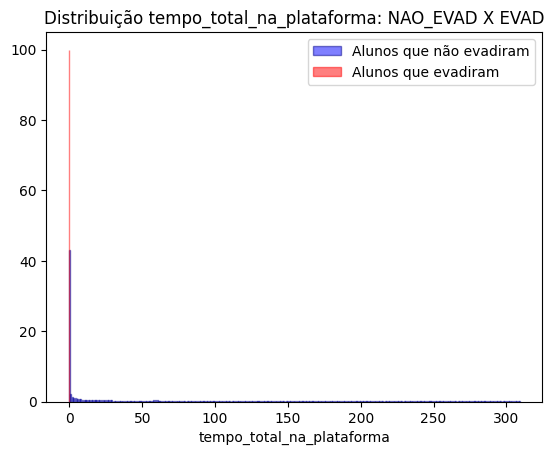

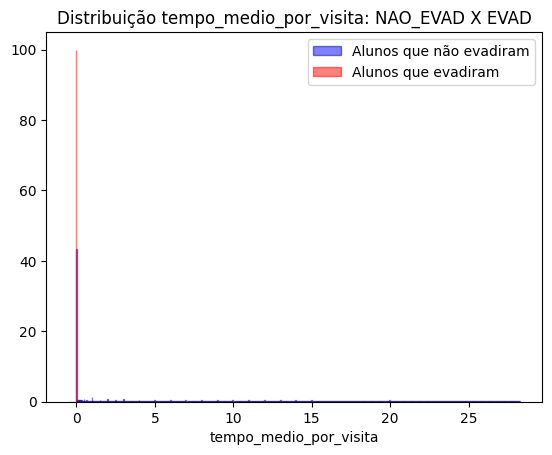

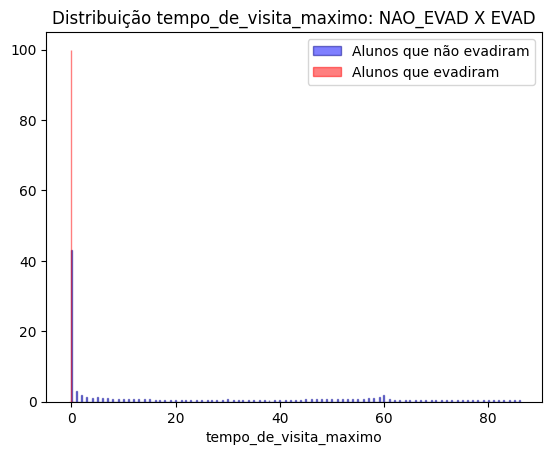

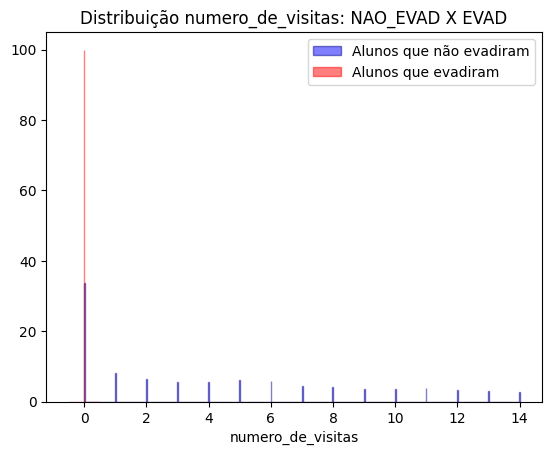

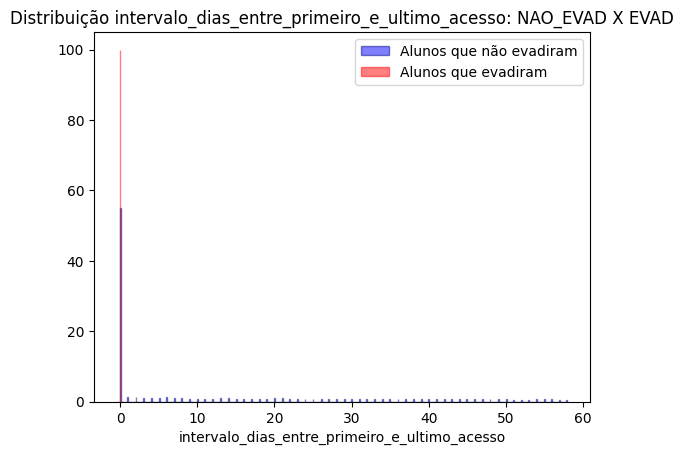

In [80]:
perc_corte = 0.75

plot_info_nao_evad_agains_evad('tempo_total_na_plataforma', perc_corte)
plot_info_nao_evad_agains_evad('tempo_medio_por_visita', perc_corte)
plot_info_nao_evad_agains_evad('tempo_de_visita_maximo', perc_corte)
plot_info_nao_evad_agains_evad('numero_de_visitas', perc_corte)
plot_info_nao_evad_agains_evad('intervalo_dias_entre_primeiro_e_ultimo_acesso', perc_corte)

### Pode-se explorar a metade superior da distribuição também:

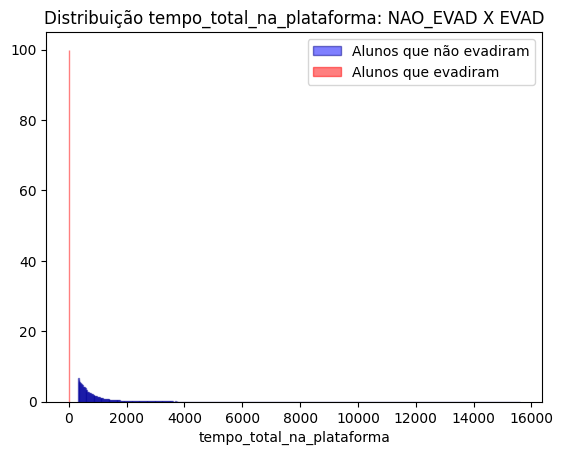

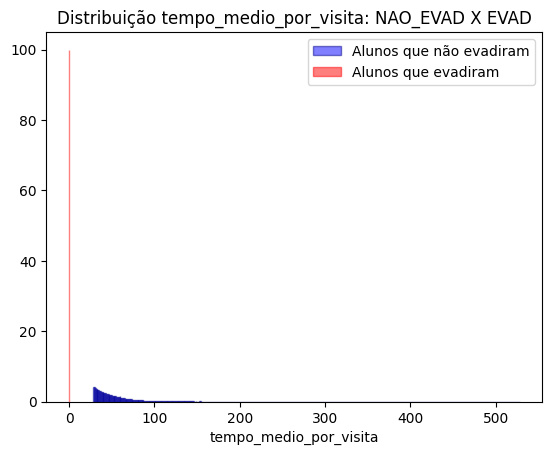

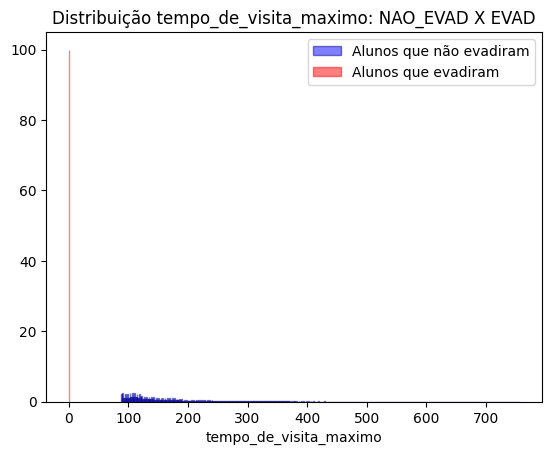

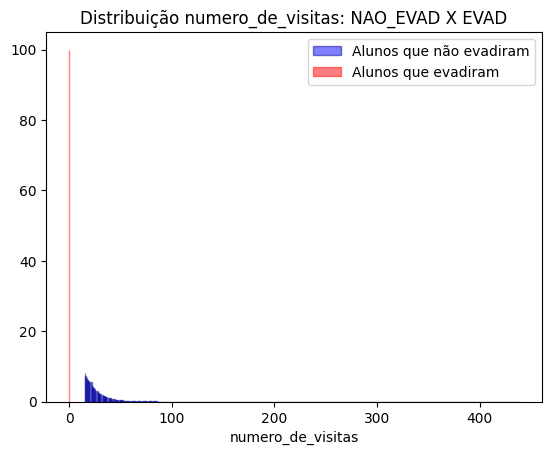

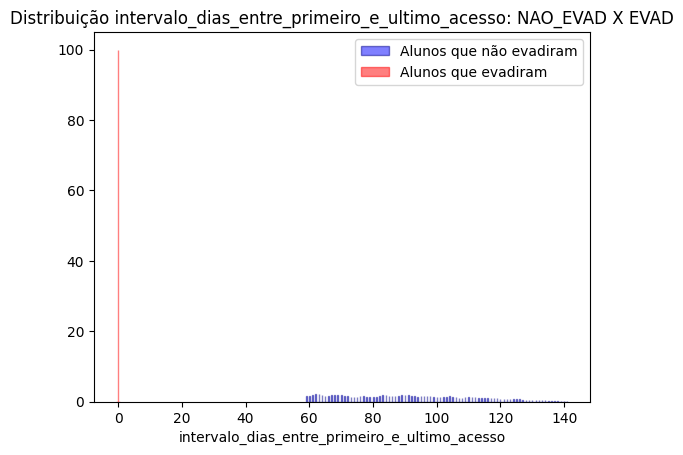

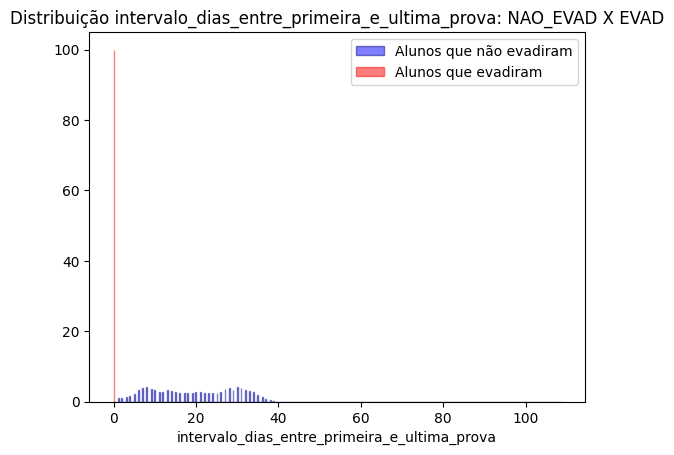

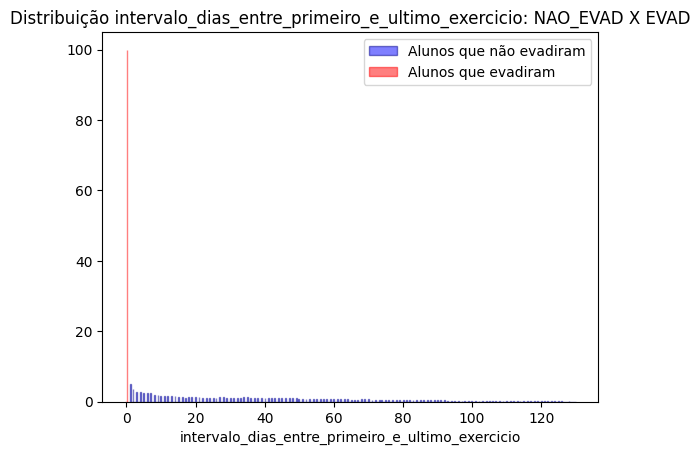

In [81]:
perc_corte = 0.75

plot_info_nao_evad_agains_evad('tempo_total_na_plataforma', perc_corte, right=False)
plot_info_nao_evad_agains_evad('tempo_medio_por_visita', perc_corte, right=False)
plot_info_nao_evad_agains_evad('tempo_de_visita_maximo', perc_corte, right=False)
plot_info_nao_evad_agains_evad('numero_de_visitas', perc_corte, right=False)
plot_info_nao_evad_agains_evad('intervalo_dias_entre_primeiro_e_ultimo_acesso', perc_corte, right=False)
plot_info_nao_evad_agains_evad('intervalo_dias_entre_primeira_e_ultima_prova', perc_corte, right=False)
plot_info_nao_evad_agains_evad('intervalo_dias_entre_primeiro_e_ultimo_exercicio', perc_corte, right=False)

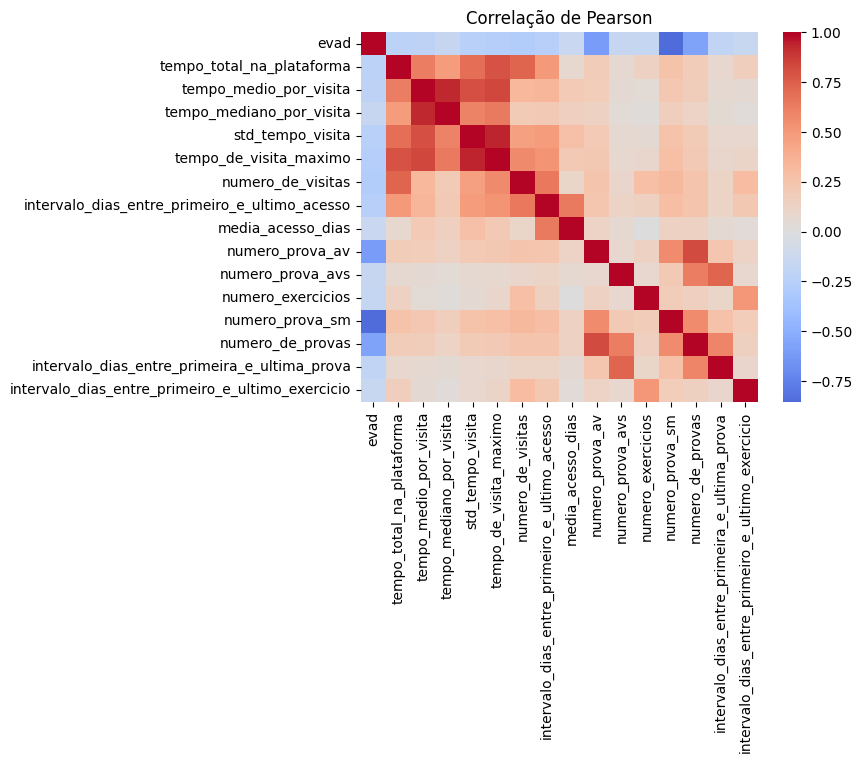

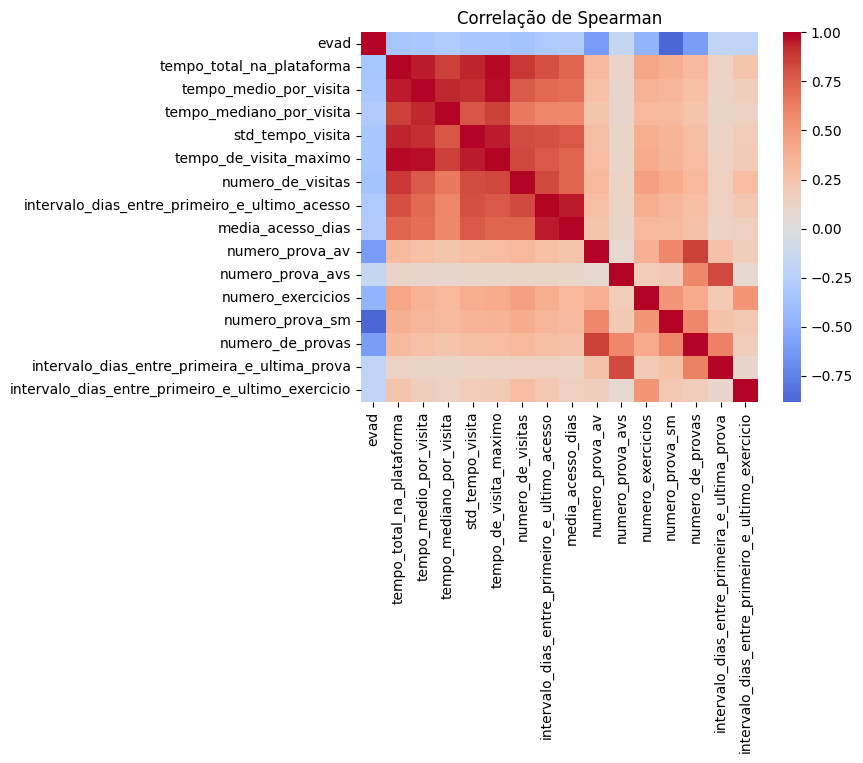

In [82]:
colunas = ['evad', 'tempo_total_na_plataforma',
            'tempo_medio_por_visita', 'tempo_mediano_por_visita',
            'std_tempo_visita', 'tempo_de_visita_maximo',
            'numero_de_visitas',
            'intervalo_dias_entre_primeiro_e_ultimo_acesso', 'media_acesso_dias',
            'numero_prova_av', 'numero_prova_avs', 'numero_exercicios',
            'numero_prova_sm', 'numero_de_provas',
            'intervalo_dias_entre_primeira_e_ultima_prova',
            'intervalo_dias_entre_primeiro_e_ultimo_exercicio']

correlation_pearson = df_features[colunas].corr(method='pearson')
sns.heatmap(correlation_pearson, annot=False, cmap='coolwarm', fmt='.2f', cbar=True, center=0)
plt.title("Correlação de Pearson")
plt.show()

correlation_spearman = df_features[colunas].corr(method='spearman')
sns.heatmap(correlation_spearman, annot=False, cmap='coolwarm', fmt='.2f', cbar=True, center=0)
plt.title("Correlação de Spearman")
plt.show()

Com base na análise exploratória acima, pode-se inferir que alunos com menor interação com a plataforma de aprendizado (menor quantidade de acessos, menor tempo) possuem maiores chances de evadir. Alunos que não fizeram nenhuma prova/exercício, ou apenas uma/um (intervalo = 0), também.

In [83]:
# Novas features:

df_features['nunca_fez_exercicios'] = df_features['data_primeiro_exercicio'].isna()
df_features['nunca_fez_avaliacoes'] = df_features['data_primeira_prova'].isna()
df_features['acesso_unico'] = df_features['primeiro_acesso'] == df_features['ultimo_acesso']

df_nao_evad = df_features[~df_features['evad']]
df_evad = df_features[df_features['evad']]

In [84]:
def analysing_boolean_relation(col):

  tbl_nao_evad = pd.crosstab(df_nao_evad['evad'], df_nao_evad[col], normalize='all') * 100
  tbl_nao_evad.index = ['NAO_EVAD']
  tbl_nao_evad.columns = [f'{col}_False', f'{col}_True']
  print(tbl_nao_evad)

  tbl_evad = pd.crosstab(df_evad['evad'], df_evad[col], normalize='all') * 100
  tbl_evad.index = ['EVAD    ']
  tbl_evad.columns = [f'{col}_False', f'{col}_True']
  print(tbl_evad)

In [85]:
analysing_boolean_relation('nunca_fez_exercicios')

          nunca_fez_exercicios_False  nunca_fez_exercicios_True
NAO_EVAD                   62.822235                  37.177765
          nunca_fez_exercicios_False  nunca_fez_exercicios_True
EVAD                        11.91474                   88.08526


In [86]:
analysing_boolean_relation('nunca_fez_avaliacoes')

          nunca_fez_avaliacoes_False  nunca_fez_avaliacoes_True
NAO_EVAD                   90.938697                   9.061303
          nunca_fez_avaliacoes_False  nunca_fez_avaliacoes_True
EVAD                       29.576742                  70.423258


In [87]:
analysing_boolean_relation('acesso_unico')

          acesso_unico_False  acesso_unico_True
NAO_EVAD           67.499908          32.500092
          acesso_unico_False  acesso_unico_True
EVAD                32.50038           67.49962


Pode-se ver também que os alunos que evadiram, em comparação com os que não evadiram, possuem uma maior incidência de hábitos como: não fazer nenhum exercício, não fazer nenhuma avaliação (AV e AVS) e acessar a plataforma uma única vez.

In [88]:
# Recuperando as features existentes:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1477825 entries, 0 to 1477824
Data columns (total 28 columns):
 #   Column                                            Non-Null Count    Dtype         
---  ------                                            --------------    -----         
 0   MATRICULA                                         1477825 non-null  object        
 1   DISCIPLINA                                        1477825 non-null  object        
 2   KEY                                               1477825 non-null  object        
 3   tempo_total_na_plataforma                         1477825 non-null  float64       
 4   tempo_medio_por_visita                            1477825 non-null  float64       
 5   tempo_mediano_por_visita                          1477825 non-null  float64       
 6   std_tempo_visita                                  1477825 non-null  float64       
 7   tempo_de_visita_maximo                            1477825 non-null  float64       
 8   pr

In [89]:
# Obtendo o X e o Y das previsões:

features = [col for col in df_features.columns if not pd.api.types.is_datetime64_any_dtype(df_features[col])]
features = [col for col in features if col not in ['MATRICULA', 'DISCIPLINA', 'KEY', 'primeiro_acesso', 'ultimo_acesso', 'numero_prova_sm', 'evad']]
features = [col for col in features if col not in ['nunca_fez_exercicios', 'nunca_fez_avaliacoes', 'numero_de_provas', 'acesso_unico']] # Medidas redundantes

df_features[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1477825 entries, 0 to 1477824
Data columns (total 13 columns):
 #   Column                                            Non-Null Count    Dtype  
---  ------                                            --------------    -----  
 0   tempo_total_na_plataforma                         1477825 non-null  float64
 1   tempo_medio_por_visita                            1477825 non-null  float64
 2   tempo_mediano_por_visita                          1477825 non-null  float64
 3   std_tempo_visita                                  1477825 non-null  float64
 4   tempo_de_visita_maximo                            1477825 non-null  float64
 5   numero_de_visitas                                 1477825 non-null  float64
 6   intervalo_dias_entre_primeiro_e_ultimo_acesso     1477825 non-null  float64
 7   media_acesso_dias                                 1477825 non-null  float64
 8   numero_prova_av                                   1477825 non-null  floa

In [90]:
# Dados desbalanceados?
df_features['evad'].value_counts()/len(df_features)*100

,count
evad,
False,64.412566
True,35.587434


In [91]:
features = df_features[features]
target = df_features['evad']

# Separando entre treino, validação e teste:
x_train, x_val, y_train, y_val = train_test_split(features, target, test_size=0.2, random_state=42)

## Modelos de Previsão

**Random Forest:** foi escolhido por ser robusto ao lidar com dados não lineares, o que permite capturar padrões em problemas com múltiplas interações entre variáveis. Além disso, a capacidade de paralelizar o treinamento do modelo (n_jobs=-1) resulta em maior eficiência computacional em datasets maiores. O Random Forest também fornece métricas de importância das variáveis, permitindo a identificação de fatores relevantes para a previsão.

**Regressão Logística**: foi escolhida pela sua alta interpretabilidade. Embora o Random Forest permita acessar a importância das variáveis, os coeficientes da Regressão Logística oferecem uma interpretação mais direta: o sinal dos coeficientes indica a direção do efeito (positivo ou negativo), enquanto sua magnitude reflete a intensidade do impacto. Essa característica é essencial para o problema em questão, que demanda insights em relação a fatores que aumentam as chances de evasão.

In [92]:
# Treinando o Modelo: Random Forest

model = RandomForestClassifier(n_estimators=100, random_state=42)
param_grid = {'max_depth': [2, 3, 5]}
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5]})

In [93]:
print("Melhor Depth:", grid_search.best_params_)

Melhor Depth: {'max_depth': 5}


In [94]:
best_model = grid_search.best_estimator_
y_predict = best_model.predict(x_val)

In [95]:
y_previsto = y_predict
y_real = y_val
n_casas = 4

accuracy = accuracy_score(y_real, y_previsto)
precision = precision_score(y_real, y_previsto, average='macro')
recall = recall_score(y_real, y_previsto, average='macro')
f1 = f1_score(y_real, y_previsto, average='macro')
auc = roc_auc_score(y_real, y_previsto)

print(f"Accuracy: {round(accuracy, n_casas)}")
print(f"Precision: {round(precision, n_casas)}")
print(f"Recall: {round(recall, n_casas)}")
print(f"F1 Score: {round(f1, n_casas)}")
print(f"AUC: {round(auc, n_casas)}")

Accuracy: 0.8529
Precision: 0.8584
Recall: 0.8154
F1 Score: 0.8301
AUC: 0.8154


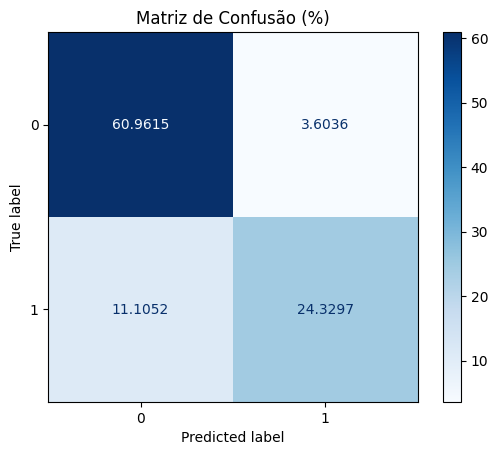

In [96]:
# Matriz de Confusão:

cm = confusion_matrix(y_real, y_previsto)
cm = cm / cm.sum() * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues, values_format=f".{n_casas}f")

plt.title(f"Matriz de Confusão (%)")
plt.show()

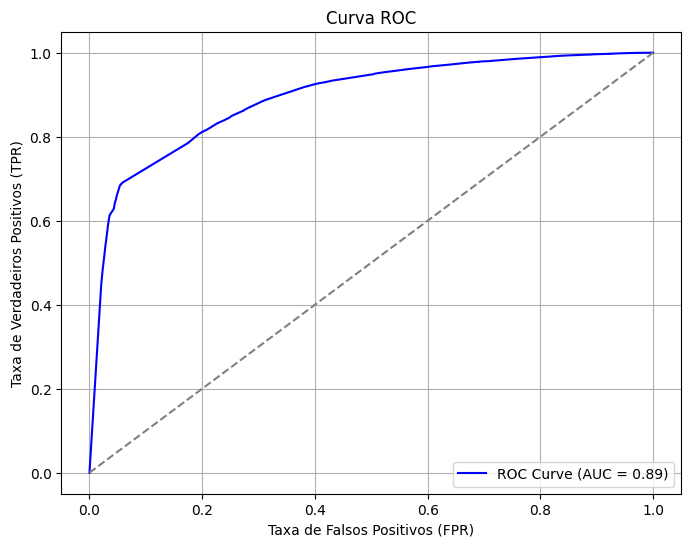

In [97]:
# Curva ROC:

y_prob = best_model.predict_proba(x_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [98]:
importancia_das_features = best_model.feature_importances_

df_importancia = pd.DataFrame({
    'Feature': x_val.columns,
    'Importance': importancia_das_features
}).sort_values(by='Importance', ascending=False)

df_importancia

,Feature,Importance
8,numero_prova_av,0.476789
10,numero_exercicios,0.259195
5,numero_de_visitas,0.065585
1,tempo_medio_por_visita,0.040499
3,std_tempo_visita,0.038367
0,tempo_total_na_plataforma,0.032448
9,numero_prova_avs,0.020031
4,tempo_de_visita_maximo,0.019871
11,intervalo_dias_entre_primeira_e_ultima_prova,0.017153
7,media_acesso_dias,0.010963


In [99]:
# Treinando o Modelo: Regressão Logística

model = LogisticRegression()

dict_coef = {}
dict_p_value = {}

qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=0)

x_train_norm = pd.DataFrame(qt.fit_transform(x_train), columns=x_train.columns)
x_val_norm = pd.DataFrame(qt.fit_transform(x_val), columns=x_val.columns)

for col in x_train.columns:

    model.fit(x_train_norm[col].values.reshape(-1, 1), y_train)

    coeficiente = model.coef_[0][0]
    intercepto = model.intercept_[0]

    y_pred = model.predict_proba(x_val_norm[col].values.reshape(-1, 1))

    residuals = y_val - y_pred[:, 1]
    stderr = np.std(residuals) / np.sqrt(len(residuals))

    t_value = coeficiente / stderr
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_value), df=len(y_train) - 1))

    dict_coef[col] = coeficiente
    dict_p_value[col] = p_value

In [100]:
coeficientes = [value for value in dict_coef.values()]
variavel = [key for key in dict_coef.keys()]
p_valores = [value for value in dict_p_value.values()]

df_results = pd.DataFrame({'coeficiente': coeficientes, 'p-valor' : p_valores}, index=variavel)
df_results['modulo_efeito'] = df_results['coeficiente'].abs()
df_results['efeito'] = np.where(df_results['coeficiente'] > 0, 'POSITIVO', 'NEGATIVO')
df_results['efeito_chance_%'] = (np.exp(df_results['coeficiente']) - 1)*100

df_results.sort_values(by=['modulo_efeito'], ascending=[False])

,coeficiente,p-valor,modulo_efeito,efeito,efeito_chance_%
numero_prova_av,-4.429469,0.0,4.429469,NEGATIVO,-98.807918
numero_exercicios,-3.273033,0.0,3.273033,NEGATIVO,-96.210866
intervalo_dias_entre_primeiro_e_ultimo_exercicio,-2.552697,0.0,2.552697,NEGATIVO,-92.212860
numero_de_visitas,-2.240227,0.0,2.240227,NEGATIVO,-89.356569
tempo_total_na_plataforma,-2.100691,0.0,2.100691,NEGATIVO,-87.762812
tempo_de_visita_maximo,-2.025698,0.0,2.025698,NEGATIVO,-86.809831
std_tempo_visita,-1.965832,0.0,1.965832,NEGATIVO,-85.996066
tempo_medio_por_visita,-1.957020,0.0,1.957020,NEGATIVO,-85.872118
intervalo_dias_entre_primeira_e_ultima_prova,-1.946260,0.0,1.946260,NEGATIVO,-85.719285
intervalo_dias_entre_primeiro_e_ultimo_acesso,-1.840993,0.0,1.840993,NEGATIVO,-84.134016


Fatores como:


*   o número de provas realizadas (+ provas realizadas = - chance de evasão)
*   o número de exercícios realizados (- exercícios realizados = + chance de evasão)
*   o acesso à plataforma (- acesso/número de visitas = + chance de evasão)
*   tempo na plataforma (- tempo = + chance de evasão)
*   intervalo de dias entre o primeiro e o último exercício/prova (- intervalo entre primeiro e último exercício/prova = + chance de evasão)

foram identificados como essenciais para as chances de evasão. Esses resultados estão em conformidade com as observações feitas durante a análise exploratória (baixa interação com a plataforma = evasão).

Com base nesses insights, podem ser adotadas ações específicas para desincentivar a evasão, como:

*  Incentivar a realização de mais provas e exercícios: programas de gamificação ou metas de aprendizado podem motivar os estudantes a se engajarem mais com o conteúdo e a prática. Oferecer algumas provas e exercícios exclusivamente em formato síncrono também pode ser uma estratégia eficaz para evitar que os alunos posterguem as atividades e, consequentemente, deixem de finalizá-las.

*  Estímulo ao acesso frequente à plataforma: notificações personalizadas, lembretes de atividades pendentes, conteúdos novos e até uma ofensiva (semelhante ao Duolinguo) podem incentivar visitas diárias ou semanais.

*  Aumentar o intervalo entre os prieiros provas/exercícios realizados: o baixo intervalo de dias entre o primeiro e o último prova/exercício pode indicar períodos de inatividade ou desinteresse. Assim, aplicar recompensas para quem realizar provas/exercícios regularmente ou completar as atividades dentro de prazos curtos pode ser um caminho promissor.

Essas ações têm o potencial de criar uma experiência mais atrativa aos alunos, desincentivando a evasão.


